# Battery Energy Storage — Optimisation Arbitrage Spot Price

## Vue d'ensemble

Ce notebook simule et optimise l'exploitation d'une batterie BESS sur le **marché spot France (EPEX)**.

**Stratégie :** Acheter de l'énergie quand le prix spot est bas (charge) et revendre via un agrégateur quand il est élevé (décharge).

**Modèle d'optimisation :** Programmation Linéaire (LP — scipy HiGHS) avec **horizon roulant 2 fenêtres/jour** :
- **00h00** — plan 24h basé sur les prix du jour J (publiés à J-1 13h sur EPEX Day-Ahead)
- **13h00** — re-planification heures 13h-23h(J) + 00h-23h(J+1) dès publication des prix J+1

**Modèles physiques :**
- Puissance limitée par le C-rate ET le raccordement Enedis
- Rendement aller-retour (charge + décharge séparément)
- Vieillissement linéaire par cycles équivalents (FEC)
- Plage SOC configurable (protection batterie)

**Unités :** kW, kWh, EUR/kWh, EUR/MWh

---
*Données : EPEX Spot France — prix spot horaires historiques (EUR/MWh), heure locale France*

In [ ]:
%matplotlib inline

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import linprog
from datetime import date, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Libraries loaded OK')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  PARAMETRES — modifier selon votre projet
# ═══════════════════════════════════════════════════════════════════════════

# ── Batterie ────────────────────────────────────────────────────────────────
CAPACITY_KWH    = 5680.0    # Capacite nominale                    [kWh]
C_RATE          = 0.5       # C-rate : P_max = C x Capacite        [h-1]
CONNECTION_KW   = 3000.0    # Puissance raccordement Enedis         [kW]
EFF_ROUNDTRIP   = 0.97      # Rendement aller-retour (charge x dech) [-]
AGING_PER_FEC   = 1e-5      # Perte capacite par cycle equivalent   [-/FEC]
CAPACITY_EOL    = 0.80      # Fin de vie (80 % capacite nominale)   [-]

# ── Etat de charge (SOC) ────────────────────────────────────────────────────
SOC_MIN_PCT     = 0.10      # SOC minimum  (10 %)
SOC_MAX_PCT     = 0.90      # SOC maximum  (90 %)
SOC_INIT_PCT    = 0.50      # SOC initial  (50 %)

# ── Agregateur ──────────────────────────────────────────────────────────────
AGGREGATOR_SPREAD = 0.000   # Spread revente vs spot  [EUR/kWh]

# ── Filtre spread minimum de decharge ───────────────────────────────────────
#   La decharge est bloquee si :
#     prix_actuel - prix_derniere_charge < MIN_DISCHARGE_SPREAD_MWH / 1000
#   Mettre a 0 pour desactiver.
#   Valeur typique : 10-20 EUR/MWh (couvre les frais + marge minimale)
MIN_DISCHARGE_SPREAD_MWH = 15.0   # [EUR/MWh]

# ── Chemins fichiers ────────────────────────────────────────────────────────
START_DATE      = date(2025, 1, 1)
CSV_DATA_PATH   = 'data_France_historical-spot_price_hourly.csv'
OUTPUT_CSV_PATH = 'battery_optimization_results.csv'

# ── Constantes derivees (ne pas modifier) ───────────────────────────────────
ETA_C = EFF_ROUNDTRIP ** 0.5
ETA_D = EFF_ROUNDTRIP ** 0.5
P_MAX = min(C_RATE * CAPACITY_KWH, CONNECTION_KW)
MIN_DISCHARGE_SPREAD_KWH = MIN_DISCHARGE_SPREAD_MWH / 1000.0

# ── Affichage recap ──────────────────────────────────────────────────────────
print('=' * 55)
print('  CONFIGURATION BATTERIE')
print('=' * 55)
print(f'  Capacite nominale       : {CAPACITY_KWH:>10,.0f} kWh')
print(f'  C-rate                  : {C_RATE:>10.2f} h-1')
print(f'  Puissance max (P_max)   : {P_MAX:>10,.0f} kW  [= min(C×Cap, Enedis)]')
print(f'  Raccordement Enedis     : {CONNECTION_KW:>10,.0f} kW')
print(f'  Rendement aller-retour  : {EFF_ROUNDTRIP*100:>9.1f} %')
print(f'    eta_charge            : {ETA_C*100:>9.3f} %')
print(f'    eta_decharge          : {ETA_D*100:>9.3f} %')
print(f'  Plage SOC               : {SOC_MIN_PCT*100:.0f} % - {SOC_MAX_PCT*100:.0f} %')
print(f'  SOC initial             : {SOC_INIT_PCT*100:.0f} %')
print(f'  Vieillissement / FEC    : {AGING_PER_FEC:.2e}')
print(f'  Fin de vie              : {CAPACITY_EOL*100:.0f} % de la capacite nominale')
print(f'  Spread agregateur       : {AGGREGATOR_SPREAD*1000:+.2f} mEUR/kWh')
print(f'  Spread min decharge     : {MIN_DISCHARGE_SPREAD_MWH:>9.1f} EUR/MWh  ({MIN_DISCHARGE_SPREAD_KWH*1000:.1f} mEUR/kWh)')
print('=' * 55)

In [51]:
# ── Chargement et pre-traitement des donnees spot price ──────────────────────
df_raw = pd.read_csv(CSV_DATA_PATH, sep=';')

# Parsing de l'heure locale France (format : DD.MM.YYYY HH:MM)
df_raw['datetime'] = pd.to_datetime(
    df_raw['Datetime (Local)'], format='%d.%m.%Y %H:%M'
)
# Conversion EUR/MWh → EUR/kWh
df_raw['price_eur_kwh'] = (
    pd.to_numeric(df_raw['Spot Price (EUR/MWhe)'], errors='coerce') / 1000.0
)

df = (
    df_raw[['datetime', 'price_eur_kwh']]
    .dropna()
    .sort_values('datetime')
    .drop_duplicates('datetime')   # supprime doublons (heure retour DST)
    .set_index('datetime')
)

# Fenetre de simulation
df_sim = df[df.index.date >= START_DATE].copy()

print(f'Dataset complet : {df.index.min().date()} => {df.index.max().date()}  ({len(df):,} heures)')
print(f'Simulation      : {df_sim.index.min().date()} => {df_sim.index.max().date()}  ({len(df_sim):,} heures)')
print()
print(f'Statistiques spot price (EUR/kWh) depuis {START_DATE} :')
stats = df_sim['price_eur_kwh'].describe().round(6)
for k, v in stats.items():
    print(f'  {k:<8} : {v:.6f} EUR/kWh  ({v*1000:.3f} EUR/MWh)')
print()
n_neg = (df_sim['price_eur_kwh'] < 0).sum()
n_pos = (df_sim['price_eur_kwh'] > 0).sum()
print(f'Prix negatifs : {n_neg} heures ({n_neg/len(df_sim)*100:.1f}%)  <-- opportunite de charge gratuite')
print(f'Prix positifs : {n_pos} heures ({n_pos/len(df_sim)*100:.1f}%)')

Dataset complet : 2015-01-01 => 2026-04-30  (99,297 heures)
Simulation      : 2025-01-01 => 2026-04-30  (11,636 heures)

Statistiques spot price (EUR/kWh) depuis 2025-01-01 :
  count    : 11636.000000 EUR/kWh  (11636000.000 EUR/MWh)
  mean     : 0.061653 EUR/kWh  (61.653 EUR/MWh)
  std      : 0.047556 EUR/kWh  (47.556 EUR/MWh)
  min      : -0.412550 EUR/kWh  (-412.550 EUR/MWh)
  25%      : 0.020330 EUR/kWh  (20.330 EUR/MWh)
  50%      : 0.061875 EUR/kWh  (61.875 EUR/MWh)
  75%      : 0.095667 EUR/kWh  (95.667 EUR/MWh)
  max      : 0.473280 EUR/kWh  (473.280 EUR/MWh)

Prix negatifs : 671 heures (5.8%)  <-- opportunite de charge gratuite
Prix positifs : 10644 heures (91.5%)


## Optimiseur LP (Programmation Lineaire)

### Formulation mathematique

**Variables de decision** sur une fenetre de $T$ heures :
$$x = [c_0, \ldots, c_{T-1},\; d_0, \ldots, d_{T-1}] \quad [\text{kWh}]$$

avec $c_t$ = energie achetee (reseau → batterie) et $d_t$ = energie vendue (batterie → reseau)

**Objectif** (maximisation du profit) :
$$\max \sum_t \left( p^{\text{vente}}_t \cdot d_t - p^{\text{achat}}_t \cdot c_t \right)$$

**Contraintes SOC** (conservation energie, $ \forall t = 0 \ldots T-1$ ) :
$$\text{SOC}_{\min} \leq \text{SOC}_0 + \sum_{k \leq t} \left( \eta_c \cdot c_k - \frac{d_k}{\eta_d} \right) \leq \text{SOC}_{\max}$$

**Contraintes puissance** :
$$0 \leq c_t \leq P_{\max}, \quad 0 \leq d_t \leq P_{\max}$$

avec $P_{\max} = \min(\text{C-rate} \times \text{capacite}, P_{\text{Enedis}})$

In [ ]:
def optimize_schedule(prices, soc_init_kwh, capacity_kwh,
                      p_max, eta_c, eta_d,
                      soc_min_pct, soc_max_pct, agg_spread):
    # Resout le LP pour maximiser le profit sur la fenetre de T heures.
    # Retourne (charge_kw, discharge_kw) : tableaux numpy de longueur T.
    #
    # Convention :
    #   1 kWh achete  => eta_c kWh stockes dans la batterie
    #   1 kWh sorti de la batterie => eta_d kWh injectes sur le reseau
    T = len(prices)
    if T == 0:
        return np.zeros(0), np.zeros(0)

    resale      = prices + agg_spread
    soc_min_kwh = soc_min_pct * capacity_kwh
    soc_max_kwh = soc_max_pct * capacity_kwh

    # Vecteur objectif (minimisation => signe inverse du profit)
    c_obj = np.concatenate([prices, -resale])   # shape (2T,)

    # Contraintes SOC (une borne sup + une borne inf par heure)
    A_rows, b_rows = [], []
    for t in range(T):
        row          = np.zeros(2 * T)
        row[:t+1]    =  eta_c
        row[T:T+t+1] = -1.0 / eta_d
        A_rows.append(row);  b_rows.append(soc_max_kwh - soc_init_kwh)
        A_rows.append(-row); b_rows.append(soc_init_kwh - soc_min_kwh)

    # Contrainte puissance combinee : ch[t] + di[t] <= P_max pour chaque t.
    # Cela decouple les flux et empeche le solveur de produire des solutions
    # degenerees (charge et decharge simultanees) aux heures a prix quasi-nul.
    for t in range(T):
        row       = np.zeros(2 * T)
        row[t]    = 1.0        # ch[t]
        row[T + t] = 1.0       # di[t]
        A_rows.append(row)
        b_rows.append(p_max)

    bounds = [(0.0, p_max)] * T + [(0.0, p_max)] * T

    res = linprog(
        c_obj,
        A_ub=np.array(A_rows),
        b_ub=np.array(b_rows),
        bounds=bounds,
        method='highs',
    )

    if res.status != 0:
        return np.zeros(T), np.zeros(T)

    ch = np.clip(res.x[:T], 0.0, p_max)
    di = np.clip(res.x[T:], 0.0, p_max)

    # Nettoyage numerique : < 100 Wh => zero
    ch[ch < 0.1] = 0.0
    di[di < 0.1] = 0.0

    # Exclusion mutuelle : filet de securite post-LP heure par heure.
    # La contrainte ch+di<=P_max dans le LP suffit en pratique ; ce filet
    # garantit le resultat meme en cas de degenerescence numerique residuelle.
    for t in range(T):
        if ch[t] > 0.0 and di[t] > 0.0:
            delta = ch[t] * eta_c - di[t] / eta_d   # variation SOC nette [kWh]
            if delta >= 0.0:
                ch[t] = min(delta / eta_c, p_max)
                di[t] = 0.0
            else:
                ch[t] = 0.0
                di[t] = min(-delta * eta_d, p_max)

    return ch, di


# --- Test rapide de l'optimiseur -------------------------------------------
test_prices = np.array([20, 15, 10, 12, 30, 60, 80, 50, 25, 20,
                         15, 10, 12, 35, 70, 90, 85, 60, 40, 30,
                         20, 15, 12, 10]) / 1000.0   # EUR/kWh
ch_test, di_test = optimize_schedule(
    test_prices,
    soc_init_kwh = SOC_INIT_PCT * CAPACITY_KWH,
    capacity_kwh = CAPACITY_KWH,
    p_max        = P_MAX,
    eta_c        = ETA_C,
    eta_d        = ETA_D,
    soc_min_pct  = SOC_MIN_PCT,
    soc_max_pct  = SOC_MAX_PCT,
    agg_spread   = AGGREGATOR_SPREAD,
)
assert not np.any((ch_test > 0) & (di_test > 0)), "ERREUR : charge+decharge simultanee detectee !"
profit_test = (di_test * (test_prices + AGGREGATOR_SPREAD) - ch_test * test_prices).sum()
print(f'Test optimiseur OK — profit journee test : {profit_test:.2f} EUR')
print(f'  Heures de charge    : {(ch_test>0).sum()}')
print(f'  Heures de decharge  : {(di_test>0).sum()}')
print(f'  Charge+dech simul.  : {np.sum((ch_test>0)&(di_test>0))}  (doit etre 0)')

In [ ]:
def run_simulation(df_sim, params):
    # Simulation horizon roulant avec deux re-optimisations par jour :
    #   00h00  => plan AM (24h), execution heures 00h-12h
    #   13h00  => re-plan PM (11h+24h) avec le SOC REEL a 13h => heures 13h-23h
    #
    # Corrections physiques appliquees AVANT enregistrement de chaque heure :
    #   1. Seuil spread minimum (filtre decharge)
    #   2. Plafonnement au SOC headroom reel  =>  evite les energies fantomes
    #   3. Filet anti-simultaneite
    # Le SOC a 13h transmis au LP PM est le SOC REEL (apres filtres heures 0-12),
    # pas le SOC prevu par le LP AM.

    records   = []
    soc_kwh   = params['soc_init_pct'] * params['capacity_kwh']
    cap_kwh   = params['capacity_kwh']
    total_fec = 0.0

    eta_c          = params['eta_c']
    eta_d          = params['eta_d']
    min_spread_kwh = params.get('min_discharge_spread_kwh', 0.0)
    last_charge_px = None

    dates  = sorted(set(df_sim.index.date))
    day_px = {
        d: df_sim[df_sim.index.date == d]['price_eur_kwh'].values
        for d in dates
    }

    for day in dates:
        p_today = day_px[day]
        if len(p_today) != 24:
            continue

        p_max   = min(params['c_rate'] * cap_kwh, params['connection_kw'])
        soc_min = params['soc_min_pct'] * cap_kwh
        soc_max = params['soc_max_pct'] * cap_kwh

        kw = dict(
            capacity_kwh = cap_kwh,
            p_max        = p_max,
            eta_c        = eta_c,
            eta_d        = eta_d,
            soc_min_pct  = params['soc_min_pct'],
            soc_max_pct  = params['soc_max_pct'],
            agg_spread   = params['agg_spread'],
        )

        # ── Plan AM : optimisation 24h a partir du SOC reel courant ─────────
        ch_am, di_am = optimize_schedule(p_today, soc_kwh, **kw)

        # ── Plan PM : calcule a h=13 avec le SOC REEL apres execution 00h-12h
        ch_pm = di_pm = None   # sera rempli lors de h==13

        ts_idx = df_sim[df_sim.index.date == day].index

        for h in range(24):

            # A 13h00 : re-optimisation PM avec le SOC reel mesure ──────────
            if h == 13:
                tomorrow = day + timedelta(days=1)
                if tomorrow in day_px and len(day_px[tomorrow]) == 24:
                    p_pm = np.concatenate([p_today[13:], day_px[tomorrow]])
                else:
                    p_pm = p_today[13:]
                ch_pm, di_pm = optimize_schedule(p_pm, soc_kwh, **kw)

            price = float(p_today[h])
            ch_h  = float(ch_am[h])       if h < 13 else float(ch_pm[h - 13])
            di_h  = float(di_am[h])       if h < 13 else float(di_pm[h - 13])

            # ── Filtre spread minimum ─────────────────────────────────────────
            if di_h > 0 and min_spread_kwh > 0 and last_charge_px is not None:
                if price - last_charge_px < min_spread_kwh:
                    di_h = 0.0

            # ── Plafonnement physique SOC ─────────────────────────────────────
            # Limite la charge a la place disponible et la decharge a l'energie
            # disponible.  Sans ce plafonnement, le clip du SOC cree des energies
            # "fantomes" enregistrees mais non stockees physiquement.
            ch_h = min(ch_h, max(0.0, (soc_max - soc_kwh) / eta_c))
            di_h = min(di_h, max(0.0, (soc_kwh - soc_min) * eta_d))

            # ── Filet anti-simultaneite ───────────────────────────────────────
            if ch_h > 0.0 and di_h > 0.0:
                delta = ch_h * eta_c - di_h / eta_d
                if delta >= 0.0:
                    ch_h = min(delta / eta_c, p_max)
                    di_h = 0.0
                else:
                    ch_h = 0.0
                    di_h = min(-delta * eta_d, p_max)

            # Memoriser le prix de la derniere charge
            if ch_h > 0:
                last_charge_px = price

            # Mise a jour SOC (ne peut plus deborder grace au plafonnement)
            soc_kwh += ch_h * eta_c - di_h / eta_d
            soc_kwh  = float(np.clip(soc_kwh, soc_min, soc_max))

            resale   = price + params['agg_spread']
            cost_eur = ch_h * price
            rev_eur  = di_h * resale
            fec_inc  = (ch_h + di_h) / (2.0 * params['capacity_kwh'])
            total_fec += fec_inc

            records.append({
                'datetime'               : ts_idx[h],
                'spot_price_eur_mwh'    : round(price * 1000,         4),
                'spot_price_eur_kwh'    : round(price,                 6),
                'resale_price_eur_kwh'  : round(resale,               6),
                'charge_from_grid_kwh'  : round(ch_h,                 3),
                'discharge_to_grid_kwh' : round(di_h,                 3),
                'net_flow_kwh'          : round(ch_h - di_h,          3),
                'soc_kwh'               : round(soc_kwh,              3),
                'soc_pct'               : round(soc_kwh / cap_kwh * 100, 2),
                'capacity_kwh'          : round(cap_kwh,              3),
                'purchase_cost_eur'     : round(cost_eur,             4),
                'resale_revenue_eur'    : round(rev_eur,              4),
                'net_revenue_eur'       : round(rev_eur - cost_eur,   4),
                'cumulative_fec'        : round(total_fec,            4),
            })

        # ── Vieillissement en fin de journee ─────────────────────────────────
        cap_kwh = params['capacity_kwh'] * max(
            params['capacity_eol'],
            1.0 - params['aging_per_fec'] * total_fec,
        )

    df_res = pd.DataFrame(records).set_index('datetime')

    # Verification finale
    n_simul = int(((df_res['charge_from_grid_kwh'] > 0) &
                   (df_res['discharge_to_grid_kwh'] > 0)).sum())
    if n_simul > 0:
        print(f'  AVERTISSEMENT : {n_simul} heures charge+decharge simultanees residuelles.')
    else:
        print('  Verification OK : aucune heure charge+decharge simultanee.')

    # Verification bilan energetique
    ch_tot = df_res['charge_from_grid_kwh'].sum()
    di_tot = df_res['discharge_to_grid_kwh'].sum()
    ratio  = ch_tot / di_tot if di_tot > 0 else float('inf')
    eta_rt = params['eta_c'] * params['eta_d']
    print(f'  Bilan energetique : achat={ch_tot:,.0f} kWh | vente={di_tot:,.0f} kWh | '
          f'ratio={ratio:.4f} (attendu ~{1/eta_rt:.4f})')

    return df_res

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  PANNEAU PARAMETRES INTERACTIF
# ══════════════════════════════════════════════════════════════════════════════
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _HAS_WIDGETS = True
except ImportError:
    _HAS_WIDGETS = False
    print('ipywidgets non installe. Executer :  pip install ipywidgets')

if _HAS_WIDGETS:
    import time as _time

    _sty = {'description_width': '220px'}
    _lw  = widgets.Layout(width='380px')
    _ls  = widgets.Layout(width='380px')

    w_cap  = widgets.BoundedFloatText(
        value=CAPACITY_KWH, min=10, max=100_000, step=100,
        description='Capacite (kWh) :', style=_sty, layout=_lw)
    w_cr   = widgets.FloatSlider(
        value=C_RATE, min=0.10, max=2.00, step=0.05,
        description='C-rate (h-1) :', style=_sty, layout=_ls, readout_format='.2f')
    w_conn = widgets.BoundedFloatText(
        value=CONNECTION_KW, min=10, max=100_000, step=100,
        description='Raccordement Enedis (kW) :', style=_sty, layout=_lw)
    w_eff  = widgets.FloatSlider(
        value=EFF_ROUNDTRIP, min=0.70, max=0.999, step=0.005,
        description='Rendement aller-retour :', style=_sty, layout=_ls, readout_format='.3f')
    w_age  = widgets.FloatText(
        value=AGING_PER_FEC,
        description='Vieillissement / FEC :', style=_sty, layout=_lw)
    w_eol  = widgets.FloatSlider(
        value=CAPACITY_EOL, min=0.50, max=0.95, step=0.05,
        description='Capacite fin de vie :', style=_sty, layout=_ls, readout_format='.0%')
    w_smin = widgets.FloatSlider(
        value=SOC_MIN_PCT, min=0.00, max=0.30, step=0.01,
        description='SOC minimum :', style=_sty, layout=_ls, readout_format='.0%')
    w_smax = widgets.FloatSlider(
        value=SOC_MAX_PCT, min=0.70, max=1.00, step=0.01,
        description='SOC maximum :', style=_sty, layout=_ls, readout_format='.0%')
    w_init = widgets.FloatSlider(
        value=SOC_INIT_PCT, min=0.10, max=0.90, step=0.05,
        description='SOC initial :', style=_sty, layout=_ls, readout_format='.0%')
    w_spr  = widgets.FloatText(
        value=AGGREGATOR_SPREAD,
        description='Spread agregateur (EUR/kWh) :', style=_sty, layout=_lw)
    w_dsp  = widgets.FloatSlider(
        value=MIN_DISCHARGE_SPREAD_MWH, min=0.0, max=50.0, step=1.0,
        description='Spread min decharge (EUR/MWh) :',
        style={'description_width': '220px', 'handle_color': '#d35400'},
        layout=_ls, readout_format='.0f')

    btn = widgets.Button(
        description='  LANCER LA SIMULATION',
        button_style='success', icon='play',
        layout=widgets.Layout(width='280px', height='44px', margin='10px 0 4px 0'),
    )
    out_widget = widgets.Output(
        layout=widgets.Layout(
            border='1px solid #b0c4de', border_radius='7px',
            padding='10px 14px', margin_top='6px',
        )
    )

    def _on_run(b):
        global CAPACITY_KWH, C_RATE, CONNECTION_KW, EFF_ROUNDTRIP
        global AGING_PER_FEC, CAPACITY_EOL, SOC_MIN_PCT, SOC_MAX_PCT
        global SOC_INIT_PCT, AGGREGATOR_SPREAD, ETA_C, ETA_D, P_MAX
        global MIN_DISCHARGE_SPREAD_MWH, MIN_DISCHARGE_SPREAD_KWH
        global params, results

        CAPACITY_KWH              = w_cap.value
        C_RATE                    = w_cr.value
        CONNECTION_KW             = w_conn.value
        EFF_ROUNDTRIP             = w_eff.value
        AGING_PER_FEC             = w_age.value
        CAPACITY_EOL              = w_eol.value
        SOC_MIN_PCT               = w_smin.value
        SOC_MAX_PCT               = w_smax.value
        SOC_INIT_PCT              = w_init.value
        AGGREGATOR_SPREAD         = w_spr.value
        MIN_DISCHARGE_SPREAD_MWH  = w_dsp.value

        ETA_C = EFF_ROUNDTRIP ** 0.5
        ETA_D = EFF_ROUNDTRIP ** 0.5
        P_MAX = min(C_RATE * CAPACITY_KWH, CONNECTION_KW)
        MIN_DISCHARGE_SPREAD_KWH = MIN_DISCHARGE_SPREAD_MWH / 1000.0

        params = dict(
            capacity_kwh             = CAPACITY_KWH,
            c_rate                   = C_RATE,
            connection_kw            = CONNECTION_KW,
            eta_c                    = ETA_C,
            eta_d                    = ETA_D,
            soc_min_pct              = SOC_MIN_PCT,
            soc_max_pct              = SOC_MAX_PCT,
            soc_init_pct             = SOC_INIT_PCT,
            agg_spread               = AGGREGATOR_SPREAD,
            aging_per_fec            = AGING_PER_FEC,
            capacity_eol             = CAPACITY_EOL,
            min_discharge_spread_kwh = MIN_DISCHARGE_SPREAD_KWH,
        )

        b.description = '  Simulation en cours...'
        b.disabled    = True

        with out_widget:
            clear_output(wait=True)
            print(f'Config : {CAPACITY_KWH:.0f} kWh | C={C_RATE:.2f} | P_max={P_MAX:.0f} kW | '
                  f'eta={EFF_ROUNDTRIP*100:.1f}% | aging={AGING_PER_FEC:.1e} | '
                  f'spread_min={MIN_DISCHARGE_SPREAD_MWH:.0f} EUR/MWh')
            print()
            t0      = _time.time()
            results = run_simulation(df_sim, params)
            elapsed = _time.time() - t0

            n_days     = results.index.normalize().nunique()
            net_profit = results['net_revenue_eur'].sum()
            avg_daily  = net_profit / n_days
            cap_final  = results['capacity_kwh'].iloc[-1]
            fec_total  = results['cumulative_fec'].iloc[-1]
            total_rev  = results['resale_revenue_eur'].sum()
            total_cost = results['purchase_cost_eur'].sum()

            print(f'Termine en {elapsed:.1f} s  |  {len(results):,} heures  |  {n_days} jours')
            print('=' * 52)
            print(f'  Chiffre affaires vente : {total_rev:>12,.2f} EUR')
            print(f'  Cout achat energie     : {total_cost:>12,.2f} EUR')
            print(f'  PROFIT NET             : {net_profit:>12,.2f} EUR')
            print(f'  Profit moyen / jour    : {avg_daily:>12,.2f} EUR/jour')
            print(f'  Profit annuel estime   : {avg_daily*365:>12,.0f} EUR/an')
            print(f'  FEC cumules            : {fec_total:>12.1f}')
            print(f'  Capacite finale        : {cap_final:>12.1f} kWh  '
                  f'({cap_final/CAPACITY_KWH*100:.1f}%)')
            print('=' * 52)

            # Export CSV
            _export_cols = [
                'spot_price_eur_mwh', 'spot_price_eur_kwh', 'resale_price_eur_kwh',
                'charge_from_grid_kwh', 'discharge_to_grid_kwh', 'net_flow_kwh',
                'soc_pct', 'capacity_kwh', 'purchase_cost_eur',
                'resale_revenue_eur', 'net_revenue_eur', 'cumulative_fec',
            ]
            _df_exp = results[_export_cols].copy()
            _df_exp.index.name = 'datetime'
            _df_exp.to_csv(OUTPUT_CSV_PATH, sep=';', decimal='.', encoding='utf-8-sig')
            print(f'CSV mis a jour : {OUTPUT_CSV_PATH}')

            # Export JSON parametres
            _params_export = {
                'capacity_kwh'             : CAPACITY_KWH,
                'c_rate'                   : C_RATE,
                'connection_kw'            : CONNECTION_KW,
                'p_max'                    : P_MAX,
                'eff_roundtrip'            : EFF_ROUNDTRIP,
                'eta_c'                    : round(ETA_C, 6),
                'eta_d'                    : round(ETA_D, 6),
                'aging_per_fec'            : AGING_PER_FEC,
                'capacity_eol'             : CAPACITY_EOL,
                'soc_min_pct'              : SOC_MIN_PCT,
                'soc_max_pct'              : SOC_MAX_PCT,
                'soc_init_pct'             : SOC_INIT_PCT,
                'agg_spread'               : AGGREGATOR_SPREAD,
                'min_discharge_spread_mwh' : MIN_DISCHARGE_SPREAD_MWH,
                'sim_start'                : str(START_DATE),
            }
            with open('battery_params.json', 'w', encoding='utf-8') as _f:
                json.dump(_params_export, _f, indent=2)
            print('Parametres exportes : battery_params.json')
            print()
            print('Relancer les cellules Graphiques / KPI puis battery_dashboard_generator.py.')

        b.description = '  RELANCER LA SIMULATION'
        b.disabled    = False

    btn.on_click(_on_run)

    _col1 = widgets.VBox([w_cap, w_cr, w_conn, w_eff, w_age])
    _col2 = widgets.VBox([w_eol, w_smin, w_smax, w_init, w_spr, w_dsp])
    _sep  = widgets.HTML('<div style="width:24px"></div>')

    _panel = widgets.VBox([
        widgets.HTML(
            '<h4 style="color:#1a3a5c;margin:0 0 10px 0;font-family:Segoe UI,sans-serif">'
            '&#9881;&#65039; Parametres batterie — ajuster puis cliquer Lancer</h4>'
        ),
        widgets.HBox([_col1, _sep, _col2]),
        widgets.HTML('<hr style="border:none;border-top:1px solid #d4e6f5;margin:10px 0">'),
        btn,
        out_widget,
    ])
    display(_panel)

In [ ]:
params = dict(
    capacity_kwh             = CAPACITY_KWH,
    c_rate                   = C_RATE,
    connection_kw            = CONNECTION_KW,
    eta_c                    = ETA_C,
    eta_d                    = ETA_D,
    soc_min_pct              = SOC_MIN_PCT,
    soc_max_pct              = SOC_MAX_PCT,
    soc_init_pct             = SOC_INIT_PCT,
    agg_spread               = AGGREGATOR_SPREAD,
    aging_per_fec            = AGING_PER_FEC,
    capacity_eol             = CAPACITY_EOL,
    min_discharge_spread_kwh = MIN_DISCHARGE_SPREAD_KWH,
)

print('Lancement de la simulation...')
t0      = time.time()
results = run_simulation(df_sim, params)
elapsed = time.time() - t0

print(f'Termine en {elapsed:.1f} s  =>  {len(results):,} enregistrements horaires')
print()
results.head(8)

In [56]:
# ── Indicateurs de performance (KPI) ─────────────────────────────────────────
total_rev   = results['resale_revenue_eur'].sum()
total_cost  = results['purchase_cost_eur'].sum()
net_profit  = results['net_revenue_eur'].sum()
n_days      = results.index.normalize().nunique()
avg_daily   = net_profit / n_days if n_days else 0.0

charged_kwh     = results['charge_from_grid_kwh'].sum()
discharged_kwh  = results['discharge_to_grid_kwh'].sum()
active_h        = ((results['charge_from_grid_kwh'] > 0) |
                   (results['discharge_to_grid_kwh'] > 0)).sum()
total_fec_sim   = results['cumulative_fec'].iloc[-1]
cap_final       = results['capacity_kwh'].iloc[-1]
cap_loss_pct    = (1.0 - cap_final / CAPACITY_KWH) * 100.0

print('=' * 58)
print('  RESULTATS  —  OPTIMISATION BATTERIE')
print('=' * 58)
print(f'  Periode               : {results.index[0].date()} => {results.index[-1].date()}')
print(f'  Duree                 : {n_days} jours  ({len(results):,} heures)')
print()
print(f'  Chiffre affaires vente: {total_rev:>14,.2f} EUR')
print(f'  Cout achat energie    : {total_cost:>14,.2f} EUR')
print(f'  PROFIT NET            : {net_profit:>14,.2f} EUR')
print(f'  Profit moyen / jour   : {avg_daily:>14,.2f} EUR/jour')
print(f'  Profit annuel (extrapo): {avg_daily*365:>13,.0f} EUR/an')
print()
print(f'  Energie achetee       : {charged_kwh:>14,.1f} kWh')
print(f'  Energie vendue        : {discharged_kwh:>14,.1f} kWh')
print(f'  Heures actives        : {active_h:>14,}')
print()
print(f'  FEC cumules           : {total_fec_sim:>14.1f}')
print(f'  Capacite finale       : {cap_final:>14.1f} kWh  ({100-cap_loss_pct:.2f}% de la nominale)')
print(f'  Perte capacite        : {cap_loss_pct:>13.2f} %')
print('=' * 58)

# ── Bilan mensuel ─────────────────────────────────────────────────────────────
monthly = results.resample('ME').agg(
    revenue      = ('resale_revenue_eur',    'sum'),
    cout_achat   = ('purchase_cost_eur',     'sum'),
    profit       = ('net_revenue_eur',       'sum'),
    charge_kwh   = ('charge_from_grid_kwh',  'sum'),
    vente_kwh    = ('discharge_to_grid_kwh', 'sum'),
    fec_cumul    = ('cumulative_fec',        'last'),
).round(2)
monthly.index = monthly.index.strftime('%Y-%m')
monthly['fec_du_mois'] = monthly['fec_cumul'].diff().fillna(monthly['fec_cumul'].iloc[0]).round(3)
monthly = monthly.drop(columns='fec_cumul')

print()
print('Bilan mensuel :')
print(monthly.to_string())

  RESULTATS  —  OPTIMISATION BATTERIE
  Periode               : 2025-01-01 => 2026-04-30
  Duree                 : 482 jours  (11,568 heures)

  Chiffre affaires vente:     476,445.33 EUR
  Cout achat energie    :     217,495.18 EUR
  PROFIT NET            :     258,950.15 EUR
  Profit moyen / jour   :         537.24 EUR/jour
  Profit annuel (extrapo):       196,093 EUR/an

  Energie achetee       :    7,258,963.6 kWh
  Energie vendue        :    7,043,433.7 kWh
  Heures actives        :          5,504

  FEC cumules           :         1259.0
  Capacite finale       :         5608.7 kWh  (98.75% de la nominale)
  Perte capacite        :          1.25 %

Bilan mensuel :
           revenue  cout_achat    profit  charge_kwh  vente_kwh  fec_du_mois
datetime                                                                    
2025-01   43194.70    26421.39  16773.31   353035.39  341928.88        61.18
2025-02   43348.86    29499.57  13849.29   295210.44  286355.52        51.19
2025-03   373

Sauvegarde : battery_sample_week.png


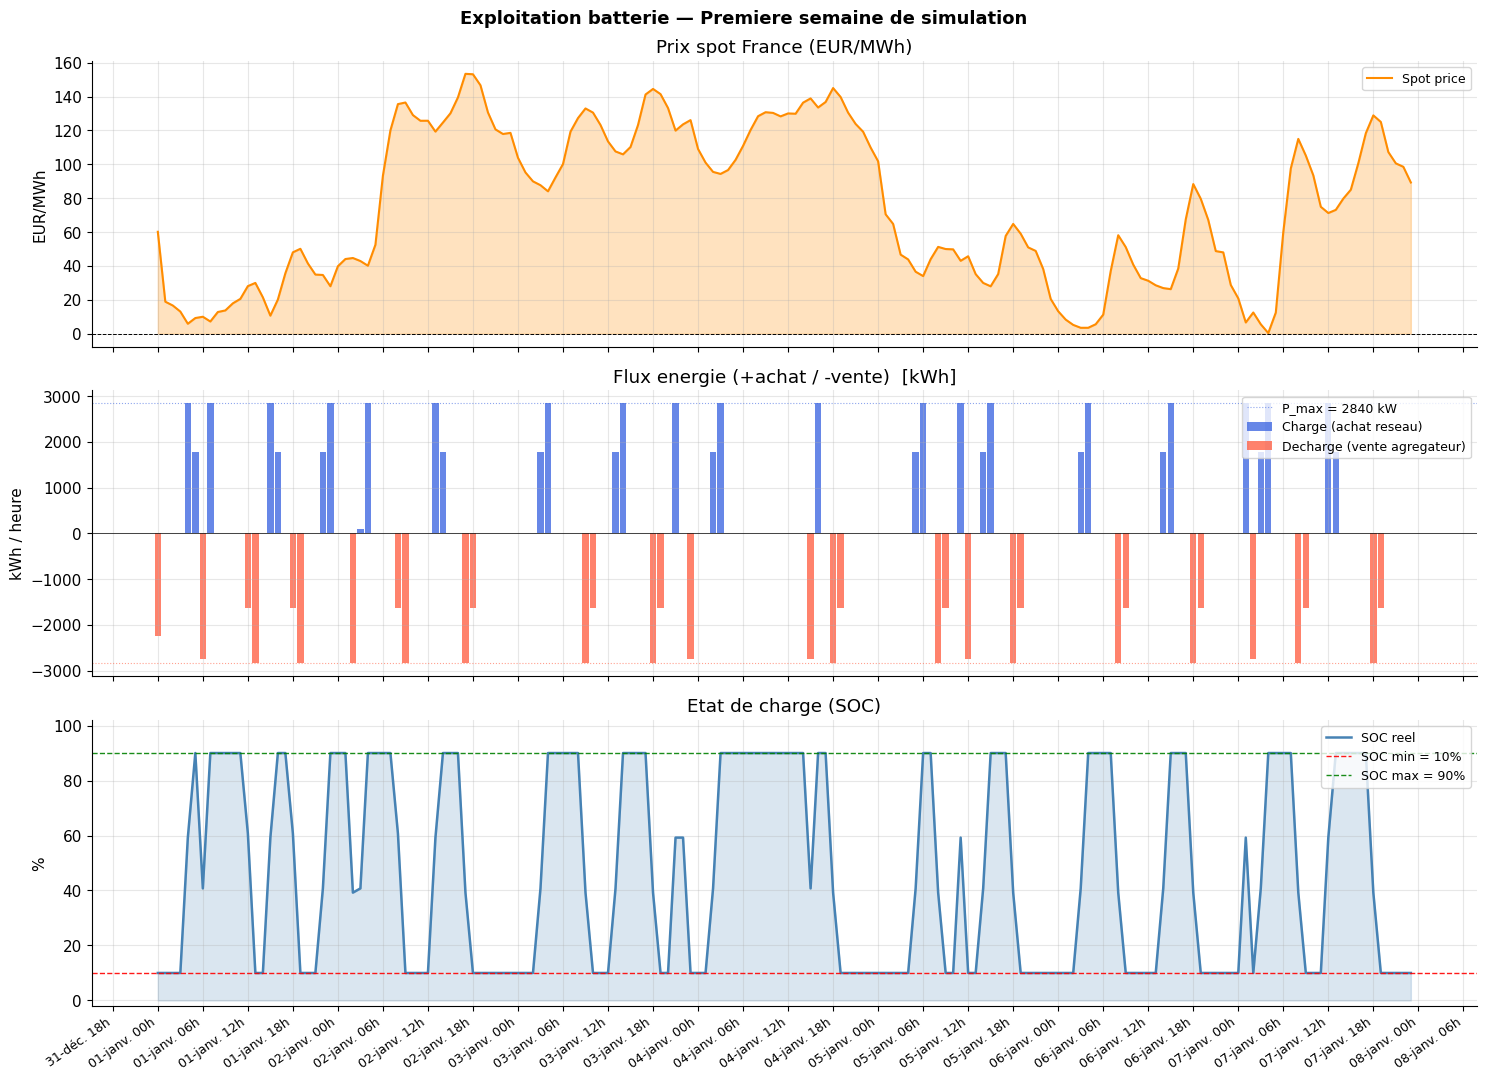

In [57]:
# ── Graphique 1 : Premiere semaine de simulation ───────────────────────────
sample = results.iloc[:24 * 7]

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
fig.suptitle('Exploitation batterie — Premiere semaine de simulation', fontsize=13, fontweight='bold')

# Prix spot
ax = axes[0]
ax.fill_between(sample.index, sample['spot_price_eur_mwh'], alpha=0.25, color='darkorange')
ax.plot(sample.index, sample['spot_price_eur_mwh'], color='darkorange', lw=1.5, label='Spot price')
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.set_ylabel('EUR/MWh')
ax.set_title('Prix spot France (EUR/MWh)')
ax.legend(fontsize=9, loc='upper right')

# Flux batterie
ax = axes[1]
w = 1.0 / 24.0 * 0.85   # largeur barre en jours
ax.bar(sample.index, sample['charge_from_grid_kwh'],
       color='royalblue', alpha=0.8, label='Charge (achat reseau)', width=w)
ax.bar(sample.index, -sample['discharge_to_grid_kwh'],
       color='tomato', alpha=0.8, label='Decharge (vente agregateur)', width=w)
ax.axhline(0, color='black', lw=0.5)
ax.axhline( P_MAX, color='royalblue', ls=':', lw=0.8, alpha=0.6, label=f'P_max = {P_MAX:.0f} kW')
ax.axhline(-P_MAX, color='tomato',    ls=':', lw=0.8, alpha=0.6)
ax.set_ylabel('kWh / heure')
ax.set_title('Flux energie (+achat / -vente)  [kWh]')
ax.legend(fontsize=9, loc='upper right')

# SOC
ax = axes[2]
ax.fill_between(sample.index, sample['soc_pct'], alpha=0.2, color='steelblue')
ax.plot(sample.index, sample['soc_pct'], color='steelblue', lw=1.8, label='SOC reel')
ax.axhline(SOC_MIN_PCT * 100, color='red',   ls='--', lw=1.0, alpha=0.9,
           label=f'SOC min = {SOC_MIN_PCT*100:.0f}%')
ax.axhline(SOC_MAX_PCT * 100, color='green', ls='--', lw=1.0, alpha=0.9,
           label=f'SOC max = {SOC_MAX_PCT*100:.0f}%')
ax.set_ylabel('%')
ax.set_ylim(-2, 102)
ax.set_title('Etat de charge (SOC)')
ax.legend(fontsize=9, loc='upper right')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %Hh'))
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('battery_sample_week.png', dpi=130, bbox_inches='tight')
print('Sauvegarde : battery_sample_week.png')
plt.show()

Sauvegarde : battery_full_period.png


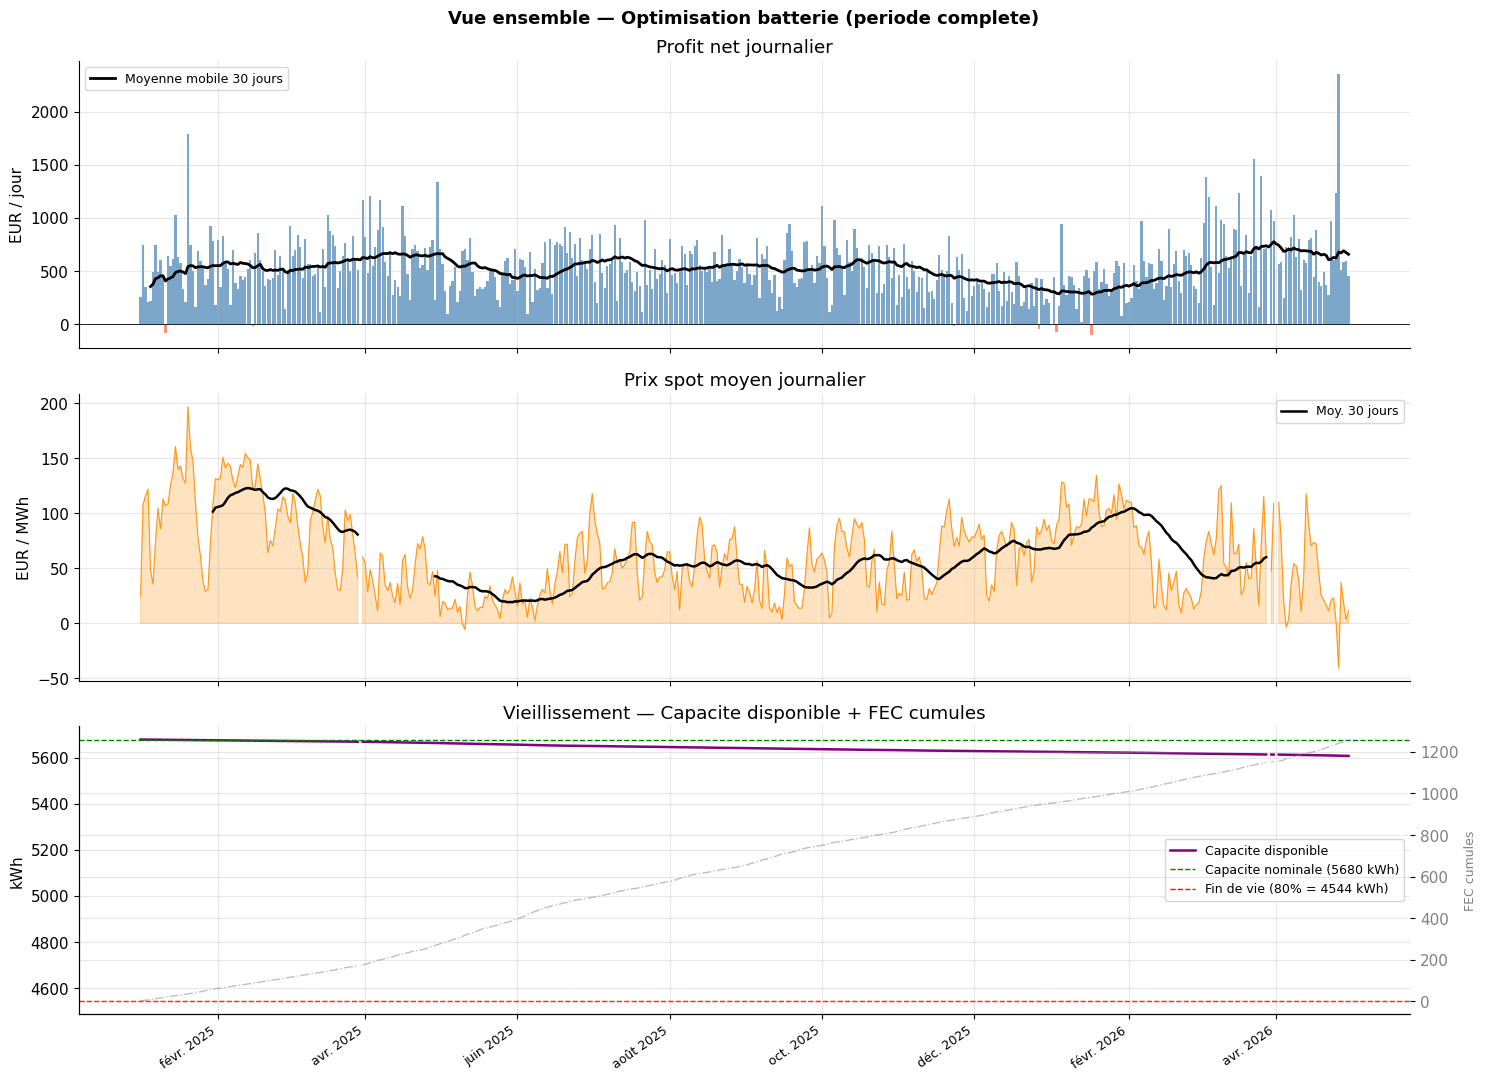

In [58]:
# ── Graphique 2 : Vue d'ensemble sur toute la periode ─────────────────────
daily = results.resample('D').agg(
    profit    = ('net_revenue_eur',    'sum'),
    avg_price = ('spot_price_eur_mwh', 'mean'),
    capacity  = ('capacity_kwh',       'last'),
    soc_avg   = ('soc_pct',            'mean'),
    fec       = ('cumulative_fec',     'last'),
)

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
fig.suptitle('Vue ensemble — Optimisation batterie (periode complete)', fontsize=13, fontweight='bold')

# Profit journalier
ax = axes[0]
colors = ['steelblue' if v >= 0 else 'tomato' for v in daily['profit']]
ax.bar(daily.index, daily['profit'], color=colors, alpha=0.7, width=0.9)
roll30 = daily['profit'].rolling(30, min_periods=5).mean()
ax.plot(daily.index, roll30, 'k-', lw=2, label='Moyenne mobile 30 jours')
ax.axhline(0, color='black', lw=0.6)
ax.set_ylabel('EUR / jour')
ax.set_title('Profit net journalier')
ax.legend(fontsize=9)

# Prix spot moyen journalier
ax = axes[1]
ax.fill_between(daily.index, daily['avg_price'], alpha=0.25, color='darkorange')
ax.plot(daily.index, daily['avg_price'], color='darkorange', lw=0.7, alpha=0.9)
ax.plot(daily.index, daily['avg_price'].rolling(30).mean(), 'k-', lw=1.8, label='Moy. 30 jours')
ax.set_ylabel('EUR / MWh')
ax.set_title('Prix spot moyen journalier')
ax.legend(fontsize=9)

# Vieillissement
ax = axes[2]
ax.plot(daily.index, daily['capacity'], color='purple', lw=1.8, label='Capacite disponible')
ax.axhline(CAPACITY_KWH,
           color='green', ls='--', lw=1.0,
           label=f'Capacite nominale ({CAPACITY_KWH:.0f} kWh)')
ax.axhline(CAPACITY_KWH * CAPACITY_EOL,
           color='red', ls='--', lw=1.0,
           label=f'Fin de vie ({CAPACITY_EOL*100:.0f}% = {CAPACITY_KWH*CAPACITY_EOL:.0f} kWh)')
ax2 = ax.twinx()
ax2.plot(daily.index, daily['fec'], color='gray', lw=1, alpha=0.5, ls='-.')
ax2.set_ylabel('FEC cumules', color='gray', fontsize=9)
ax2.tick_params(axis='y', labelcolor='gray')
ax.set_ylabel('kWh')
ax.set_title('Vieillissement — Capacite disponible + FEC cumules')
ax.legend(fontsize=9)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('battery_full_period.png', dpi=130, bbox_inches='tight')
print('Sauvegarde : battery_full_period.png')
plt.show()

Sauvegarde : battery_spread_analysis.png


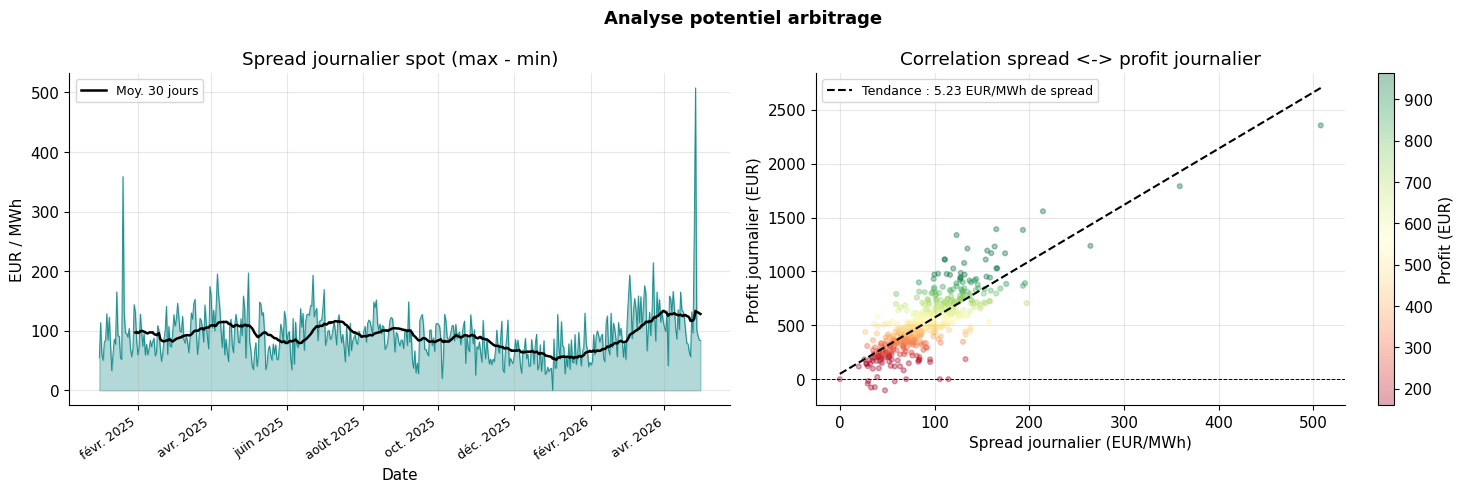

Correlation (Pearson) spread / profit : 0.806


In [59]:
# ── Graphique 3 : Analyse spread journalier et correlation avec le profit ──
daily_spread = (
    df_sim
    .groupby(df_sim.index.date)['price_eur_kwh']
    .agg(lambda x: (x.max() - x.min()) * 1000)   # EUR/MWh
)
daily_spread.index = pd.to_datetime(daily_spread.index)
daily_profit = results.resample('D')['net_revenue_eur'].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Analyse potentiel arbitrage', fontsize=13, fontweight='bold')

# Evolution du spread dans le temps
ax = axes[0]
ax.fill_between(daily_spread.index, daily_spread.values, alpha=0.3, color='teal')
ax.plot(daily_spread.index, daily_spread.values, color='teal', lw=0.7, alpha=0.8)
ax.plot(daily_spread.index,
        daily_spread.rolling(30).mean(), 'k-', lw=1.8, label='Moy. 30 jours')
ax.set_xlabel('Date')
ax.set_ylabel('EUR / MWh')
ax.set_title('Spread journalier spot (max - min)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=9)

# Scatter : spread vs profit
ax = axes[1]
spread_aligned = daily_spread.reindex(daily_profit.index)
valid = spread_aligned.notna() & daily_profit.notna()
sc = ax.scatter(
    spread_aligned[valid], daily_profit[valid],
    alpha=0.35, s=12, c=daily_profit[valid], cmap='RdYlGn',
    vmin=daily_profit.quantile(0.05), vmax=daily_profit.quantile(0.95)
)
plt.colorbar(sc, ax=ax, label='Profit (EUR)')
ax.axhline(0, color='black', lw=0.7, ls='--')
# Regression lineaire
x_v = spread_aligned[valid].values
y_v = daily_profit[valid].values
if len(x_v) > 5:
    coef = np.polyfit(x_v, y_v, 1)
    x_line = np.linspace(x_v.min(), x_v.max(), 100)
    ax.plot(x_line, np.polyval(coef, x_line), 'k--', lw=1.5,
            label=f'Tendance : {coef[0]:.2f} EUR/MWh de spread')
ax.set_xlabel('Spread journalier (EUR/MWh)')
ax.set_ylabel('Profit journalier (EUR)')
ax.set_title('Correlation spread <-> profit journalier')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('battery_spread_analysis.png', dpi=130, bbox_inches='tight')
print('Sauvegarde : battery_spread_analysis.png')
plt.show()

# Stat de correlation
corr = np.corrcoef(spread_aligned[valid], daily_profit[valid])[0, 1]
print(f'Correlation (Pearson) spread / profit : {corr:.3f}')

In [ ]:
# ── Export CSV des resultats ───────────────────────────────────────────────
export_cols = [
    'spot_price_eur_mwh', 'spot_price_eur_kwh', 'resale_price_eur_kwh',
    'charge_from_grid_kwh', 'discharge_to_grid_kwh', 'net_flow_kwh',
    'soc_pct', 'capacity_kwh', 'purchase_cost_eur',
    'resale_revenue_eur', 'net_revenue_eur', 'cumulative_fec',
]
df_export = results[export_cols].copy()
df_export.index.name = 'datetime'
df_export.to_csv(OUTPUT_CSV_PATH, sep=';', decimal='.', encoding='utf-8-sig')
print(f'Fichier exporte : {OUTPUT_CSV_PATH}')
print(f'Lignes : {len(df_export):,}   Colonnes : {len(df_export.columns)}')

# ── Export JSON des parametres (lu par battery_dashboard_generator.py) ────────
PARAMS_JSON_PATH = 'battery_params.json'
_params_export = {
    'capacity_kwh'             : CAPACITY_KWH,
    'c_rate'                   : C_RATE,
    'connection_kw'            : CONNECTION_KW,
    'p_max'                    : P_MAX,
    'eff_roundtrip'            : EFF_ROUNDTRIP,
    'eta_c'                    : round(ETA_C, 6),
    'eta_d'                    : round(ETA_D, 6),
    'aging_per_fec'            : AGING_PER_FEC,
    'capacity_eol'             : CAPACITY_EOL,
    'soc_min_pct'              : SOC_MIN_PCT,
    'soc_max_pct'              : SOC_MAX_PCT,
    'soc_init_pct'             : SOC_INIT_PCT,
    'agg_spread'               : AGGREGATOR_SPREAD,
    'min_discharge_spread_mwh' : MIN_DISCHARGE_SPREAD_MWH,
    'sim_start'                : str(START_DATE),
}
with open(PARAMS_JSON_PATH, 'w', encoding='utf-8') as _f:
    json.dump(_params_export, _f, indent=2)
print(f'Parametres exportes : {PARAMS_JSON_PATH}')

print()
print('Apercu des 6 premieres lignes :')
print(df_export.head(6).to_string())
print()
print('Apercu des 3 dernieres lignes :')
print(df_export.tail(3).to_string())